## DBScan:
Adjust $\epsilon$ radius and min_pts.

If an instance has at least min_pts (including itself) within its $\epsilon$ neighborhood, it is considered as a core point.
All instances within the $\epsilon$ neighborhood of a core point belong to one cluster.
Otherwise, the instances are considered as noise points.

DBScan does not support predict() function. We can train a KNN model instead.

dbscan.labels_                  # 每个点属于哪个cluster，-1代表noise

dbscan.core_sample_indices_     # 在X train种，第...点是core points

dbscan.components_              # 所有core points的真实坐标

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KNeighborsClassifier

dbscan = DBSCAN(eps=0.05, min_samples=5)                                    # use DBScan to find core points
dbscan.fit(X_train)

knn = KNeighborsClassifier(n_neighbors=50)                                  # use core points coordinates and their corresponding cluster labels as training data
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

y_dist, y_pred_idx = knn.kneighbors(X_new, n_neighbors=1)                   # 找离X new最近的核心点，返回X new和这个核心点的距离，以及这个核心点是第几个核心点
y_pred = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]            # 这个最近核心点的cluster label就是X new的预测cluster label
y_pred[y_dist > 0.2] = -1                                                   # 最后处理：如果X new和最近的一个核心点离得依然很远，那就将它的label改成-1，为noise point

## Gaussian Mixture Models:
Assume all data are generated by k different gaussian distributions.
Each gaussian dist has its weight, mean, and covariance. Each instance picks a gaussian dist, and generated from it with its corresponding mean and covariance.

In [ ]:
from sklearn.mixture import GaussianMixture
gm = GaussianMixture(n_components=3, n_init=10, covariance_type = )     # 假设共有3个高斯分布。用10个不同的随机初始化各跑一遍
# covariance_type: 可以提前固定住分布形状
# 'tied': 所有 cluster 共享同一个 covariance但mean不同。
# 'diag': 不允许 feature 之间相关
# 'spherical': 每个 cluster 是“球”

gm.weights_             # 学到的每个distribution的权重，均值，以及协方差
gm.means_
gm.covariances_
gm.converged_           # 查看表现最好的那一次run是否收敛

gm.predict(X_new)           # hard assignment
gm.predict_proba(X_new)     # soft assignment

/var/folders/k5/920x206s2h57jf8k30gp664r0000gn/T/ipykernel_11624/4142269923.py:52: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1],


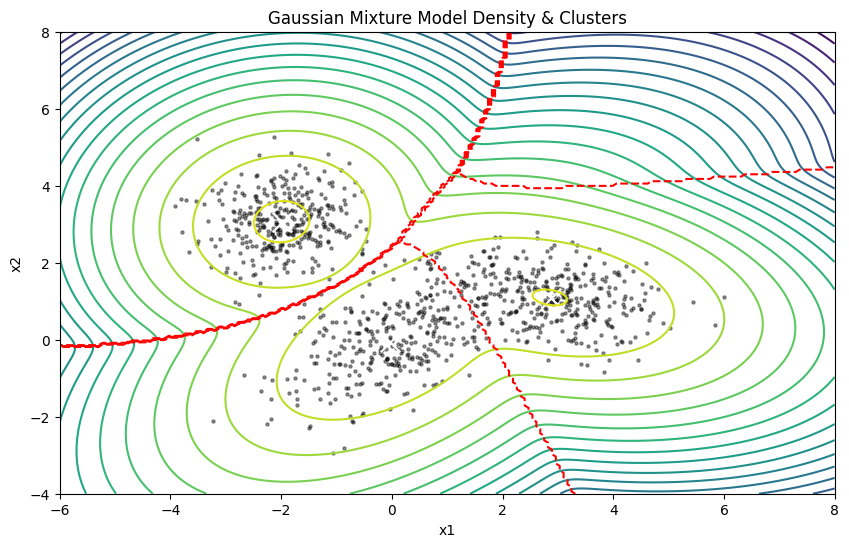

In [ ]:
# to display the decesion boundaries and countours of the fitted gaussian models: (may not be very useful, treat this as a side note)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# --------------------------
# 1. 生成数据（3个高斯混合）
# --------------------------
np.random.seed(42)

n_samples = 1000

# 3个高斯
X1 = np.random.multivariate_normal([0, 0], [[1, 0.5],[0.5, 1]], n_samples//3)
X2 = np.random.multivariate_normal([3, 1], [[1, -0.3],[-0.3, 0.5]], n_samples//3)
X3 = np.random.multivariate_normal([-2, 3], [[0.5, 0],[0, 0.5]], n_samples//3)

X = np.vstack([X1, X2, X3])

# --------------------------
# 2. 训练 GMM
# --------------------------
gmm = GaussianMixture(n_components=3, covariance_type='full', n_init=10)
gmm.fit(X)

# --------------------------
# 3. 创建网格（画等高线）
# --------------------------
x = np.linspace(-6, 8, 200)
y = np.linspace(-4, 8, 200)
Xg, Yg = np.meshgrid(x, y)
XX = np.array([Xg.ravel(), Yg.ravel()]).T

# --------------------------
# 4. 计算 density（log likelihood）
# --------------------------
Z = gmm.score_samples(XX)
Z = Z.reshape(Xg.shape)

# --------------------------
# 5. 画图
# --------------------------
plt.figure(figsize=(10, 6))

# density contour
plt.contour(Xg, Yg, Z, levels=20, cmap='viridis')

# samples
plt.scatter(X[:, 0], X[:, 1], s=5, c='black', alpha=0.4)

# cluster means
plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1],
            c='white', s=200, edgecolor='black', marker='x')

# posterior probabilities
Z_prob = gmm.predict_proba(XX)
labels = np.argmax(Z_prob, axis=1)
labels = labels.reshape(Xg.shape)

plt.contour(Xg, Yg, labels, levels=2, colors='red', linestyles='dashed')

plt.title("Gaussian Mixture Model Density & Clusters")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## Use Gaussian Mixture models for anomaly detection:
If a new instance fall in the low density region of the fitted distribution, then it is treated as outlier/anomaly point. However, the threshold of the low probability density region should be set manually.

但问题是原始数据中可能就存在outlier，在训练模型的时候模型会把outlier也学进去，从而导致performance变差。一种解决办法是先fit一次，然后通过一下方法找出outlier并删掉outlier，然后用cleaned set再重新训练一次GMM。

In [ ]:
densities = gm.score_samples(X)                         # get the densities of all training instances.
density_threshold = np.percentile(densities, 4)         # 选“最差的 4% 密度”作为异常标准
anomalies = X[densities < density_threshold]            # 小于阈值的点作为异常值

## Selecting the optimal k for GMM:
Use AIC and BIC, which penalize complex models and award models that fit data well.

Best k (AIC): 3
Best k (BIC): 3


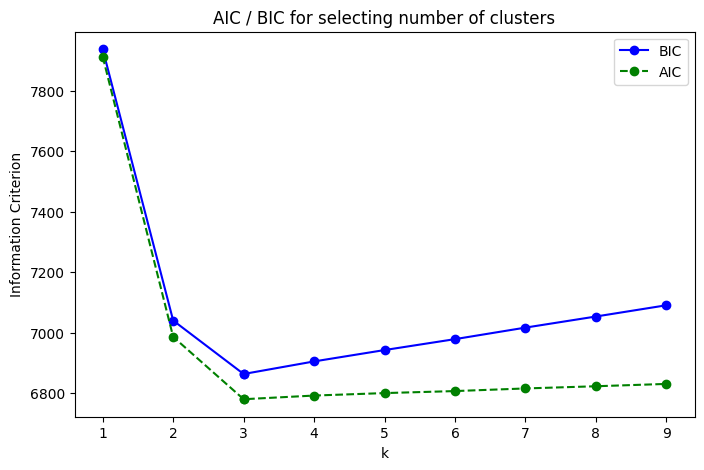

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

k_range = range(1, 10)
aic_values = []
bic_values = []

for k in k_range:                                                                                   # run a for loop, fit model k times and calculate aic/bic values after each run
    gmm = GaussianMixture(n_components=k, covariance_type='full', n_init=10, random_state=42)
    gmm.fit(X)
    aic_values.append(gmm.aic(X))
    bic_values.append(gmm.bic(X))

best_k_aic = k_range[np.argmin(aic_values)]
best_k_bic = k_range[np.argmin(bic_values)]
print("Best k (AIC):", best_k_aic)
print("Best k (BIC):", best_k_bic)

plt.figure(figsize=(8,5))
plt.plot(k_range, bic_values, 'bo-', label='BIC')
plt.plot(k_range, aic_values, 'go--', label='AIC')
plt.xlabel("k")
plt.ylabel("Information Criterion")
plt.title("AIC / BIC for selecting number of clusters")
plt.scatter(best_k_bic, min(bic_values), color='blue')      # 标出最优点
plt.scatter(best_k_aic, min(aic_values), color='green')     # 标出最优点
plt.legend()
plt.show()

## Bayesian GMM:
Set a large number of clusters, the algorithm will give weights = 0 to unnecessary clusters.

In [ ]:
from sklearn.mixture import BayesianGaussianMixture
bgm = BayesianGaussianMixture(n_components=10, n_init=10)
bgm.fit(X)
np.round(bgm.weights_, 2)